# 全历史 Walk-forward Layer Probe

本 Notebook 是独立于 `layer_probe_pipeline.ipynb` 的全历史主线。它使用冻结的中文 RoBERTa checkpoint，研究 Layer 0～12 对 `residual_signed_raw` 与 `delta_log_dispersion` 的关联、线性可解码性和未来收益。

Validation 采用年度扩展窗口：预测某年时，只允许使用该年开始前已经可知的 Label。2018～2022 用于选择 alpha；2023 final test 默认封闭。所有核心逻辑和审计写在 `src/`，Notebook 只负责执行、展示和历史回放。

In [1]:
import json
import os
import shutil
import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

CONFIGURED_ROOT = os.environ.get('CHINESE_WWM_ROBERTA_ROOT')
ROOT_CANDIDATES = [
    Path(CONFIGURED_ROOT).expanduser() if CONFIGURED_ROOT else None,
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path.home() / 'Projects' / 'chinese-wwm-roberta',
]
ROOT = next((path.resolve() for path in ROOT_CANDIDATES if path is not None and (path / 'configs' / 'layer_probe_walk_forward.yaml').is_file()), None)
assert ROOT is not None, '找不到项目根目录；请设置CHINESE_WWM_ROBERTA_ROOT'
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

from src.layer_probe_representations import (
    plot_representation_layer_norms,
    resolve_representation_directory,
    run_representation_stage,
    validate_representation_artifacts,
)
from src.layer_probe_continuous import (
    plot_fixed_head_convergence,
    run_fixed_head_analysis_stage,
    validate_fixed_head_analysis_outputs,
)
from src.layer_probe_walk_forward import (
    align_walk_forward_targets,
    parse_walk_forward_protocol,
    plot_walk_forward_fixed_head_curves,
    plot_walk_forward_probe_curves,
    run_walk_forward_fixed_head_stage,
    run_walk_forward_probe_stage,
    validate_walk_forward_fixed_head_outputs,
    validate_walk_forward_probe_outputs,
    validate_walk_forward_targets,
)
from src.layer_probe_panel import (
    plot_stock_day_summary,
    run_stock_day_panel_stage,
    validate_stock_day_artifacts,
)
from src.layer_probe_models import run_return_probe_stage
from src.layer_probe_factors import run_factor_validation_stage
from src.layer_probe_label_factors import (
    plot_label_factor_ic_curves,
    plot_layer_correlation_heatmap,
    run_label_factor_return_stage,
    run_layer_factor_correlation_stage,
    validate_label_factor_return_outputs,
    validate_layer_factor_correlation_outputs,
)
from src.layer_probe_pipeline import (
    load_layer_probe_config,
    plot_factor_summary,
    plot_return_curve,
    validate_factor_outputs,
    validate_return_probe_outputs,
)

CONFIG_PATH = ROOT / 'configs' / 'layer_probe_walk_forward.yaml'
BUNDLE_CONFIG_PATH = ROOT / 'configs' / 'probe_dataset_walk_forward.yaml'
config = load_layer_probe_config(CONFIG_PATH)
protocol = parse_walk_forward_protocol(config)
RUN_DIR = Path(config['output']['run_directory']).expanduser().resolve()
BUNDLE_DIR = Path(config['continuous_targets']['bundle_directory']).expanduser().resolve()
pd.set_option('display.max_columns', 100)
print('repo:', ROOT)
print('config:', CONFIG_PATH)
print('run:', RUN_DIR)
print('target bundle:', BUNDLE_DIR)

repo: /home/intern_fjq_2026/Projects/chinese-wwm-roberta
config: /home/intern_fjq_2026/Projects/chinese-wwm-roberta/configs/layer_probe_walk_forward.yaml
run: /home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/continuous_label_layer_probe/runs/full_history_wf_v1
target bundle: /home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/probe_dataset_walk_forward_v1


## 0. 执行开关与协议

直接 Run All 会执行完整 validation 主线。已有且 manifest 完全匹配的阶段会复用；不会覆盖不兼容产物。最终 test 与情绪附录保持关闭。

In [2]:
BUILD_TARGET_BUNDLE_IF_MISSING = True
RUN_STAGE_1_REPRESENTATIONS = True
RUN_STAGE_2A_FIXED_HEAD = True
RUN_STAGE_2A_PLUS_ASSOCIATION = True
RUN_STAGE_2B_WALK_FORWARD_PROBE = True
RUN_STAGE_3_STOCK_DAY = True
RUN_STAGE_4_DIRECT_RETURN_PROBE = True
RUN_STAGE_4B_LABEL_FACTOR_RETURNS = True
RUN_STAGE_4C_LAYER_CORRELATIONS = True
RUN_STAGE_5_6_FACTOR_VALIDATION = True
RUN_FINAL_TEST = False

assert config['strict_test']['open_final_test'] is False
assert RUN_FINAL_TEST is False, '2023 final test尚未预注册，禁止在本轮打开'
display(pd.Series(protocol.to_dict(), name='walk_forward_protocol'))

history_start                                                      2014-01-01
validation_start                                                   2018-01-01
validation_end                                                     2022-12-31
selection_label_cutoff                                             2022-12-31
test_start                                                         2023-01-01
test_end                                                           2023-12-31
test_label_cutoff                                                  2026-06-18
folds                       [{'name': 'validation_2018', 'feature_start': ...
minimum_train_rows                                                        100
minimum_evaluation_rows                                                   100
minimum_validation_folds                                                    2
Name: walk_forward_protocol, dtype: object

### 磁盘预算

全量 report representation 约 20 GiB；股票日 representation 最坏情况下接近同量级。这里在任何 GPU 写入前检查项目所在文件系统，并保留至少 15 GiB 或当前空闲空间的 20%。

In [3]:
import pyarrow.parquet as pq

text_path = Path(config['text']['path']).expanduser().resolve()
report_rows = pq.ParquetFile(text_path).metadata.num_rows
storage_bytes = 2 if config['model']['storage_dtype'] == 'float16' else 4
representation_bytes = report_rows * 13 * 768 * storage_bytes
conservative_new_bytes = representation_bytes * 2 + 3 * 1024**3
usage = shutil.disk_usage(ROOT)
reserve = max(15 * 1024**3, int(usage.free * 0.20))
disk_report = {
    'report_rows': report_rows,
    'representation_estimate_GiB': representation_bytes / 1024**3,
    'representation_plus_stock_day_worst_case_GiB': conservative_new_bytes / 1024**3,
    'free_GiB': usage.free / 1024**3,
    'required_reserve_GiB': reserve / 1024**3,
}
display(pd.Series(disk_report, name='disk_preflight'))
assert usage.free - conservative_new_bytes >= reserve, '磁盘预算不足，停止在大文件写入前'

report_rows                                     1.070181e+06
representation_estimate_GiB                     1.990178e+01
representation_plus_stock_day_worst_case_GiB    4.280356e+01
free_GiB                                        6.573469e+01
required_reserve_GiB                            1.500000e+01
Name: disk_preflight, dtype: float64

## 1. 构建全历史、无静态 split 的 Target bundle

该 bundle 保存所有有效连续 Target 及精确 `feature_available_date`、`label_available_date`。年度 fold 在训练时动态生成。若目录已存在，本 cell 只读取，不会重建并改变上游指纹。

In [4]:
bundle_manifest_path = BUNDLE_DIR / 'probe_dataset_metadata.json'
if BUILD_TARGET_BUNDLE_IF_MISSING and not bundle_manifest_path.is_file():
    subprocess.run(
        [sys.executable, str(ROOT / 'label_engineering' / 'build_probe_dataset.py'), '--config', str(BUNDLE_CONFIG_PATH)],
        check=True,
        cwd=ROOT,
    )
assert bundle_manifest_path.is_file(), f'Target bundle不存在: {bundle_manifest_path}'
bundle_manifest = json.loads(bundle_manifest_path.read_text(encoding='utf-8'))
assert bundle_manifest.get('splits') == [], 'walk-forward bundle不能预先丢弃静态split样本'
display(pd.Series(bundle_manifest['counts'], name='full_history_target_bundle'))
display(pd.DataFrame(bundle_manifest['task_counts']).head(30))

texts                  849508
targets               9157542
tasks                      21
residual_targets      1966867
dispersion_targets    7190675
Name: full_history_target_bundle, dtype: int64

,task_id,split,rows,effective_rows,weight_sum
0,delta_log_dispersion__1m__active__fh0,unassigned,341871,341871,303868.331819
1,delta_log_dispersion__1m__active__fh1,unassigned,317166,317166,281318.281877
2,delta_log_dispersion__1m__active__fh2,unassigned,153260,153260,134736.414968
3,delta_log_dispersion__1m__fixed__fh0,unassigned,535740,464904,427294.136530
4,delta_log_dispersion__1m__fixed__fh1,unassigned,499844,433325,396512.928910
5,delta_log_dispersion__1m__fixed__fh2,unassigned,293466,235714,210444.721629
6,delta_log_dispersion__1m__market__fh0,unassigned,529513,462178,425546.415444
7,delta_log_dispersion__1m__market__fh1,unassigned,494211,430857,394923.630762
8,delta_log_dispersion__1m__market__fh2,unassigned,291507,234911,209927.656908
9,delta_log_dispersion__3m__active__fh0,unassigned,449860,449860,417655.918390


## 2. 一次 backbone forward 提取 Layer 0～12

只在物理 GPU 1 空闲时启动。每批只做一次 backbone forward；存储 `[report, layer, hidden]` float16。Layer 12 固定头投影必须与模型正常输出数值一致。

/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


rows                                                                    1070181
layers                                                                       13
hidden_size                                                                 768
dtype                                                                   float16
fixed_head_rows                                                        13912353
representation_fingerprint    28736d7236b72ac08b919d6ee3f2b83955fba27e5ad50b...
head_recipe                                                              cls_fc
head_provenance                                          user_locked_assumption
Name: representation_validation, dtype: object

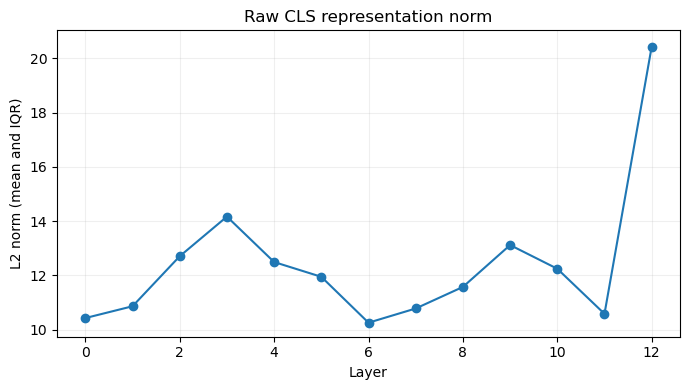

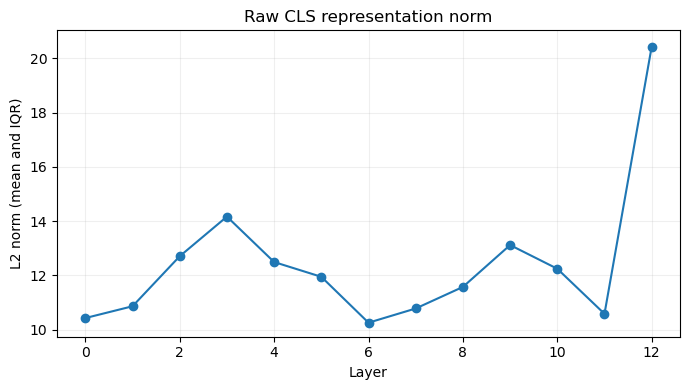

In [5]:
if RUN_STAGE_1_REPRESENTATIONS:
    run_representation_stage(config)
REPRESENTATION_DIR = resolve_representation_directory(config)
display(pd.Series(validate_representation_artifacts(REPRESENTATION_DIR), name='representation_validation'))
display(plot_representation_layer_norms(REPRESENTATION_DIR))

## 3. Scheme A：冻结原头的逐层投影

不使用任何 Label，也不训练参数。只描述原 checkpoint 的固定 `CLS → fc` 方向如何随层演化。

layers         13
transitions    12
dtype: int64

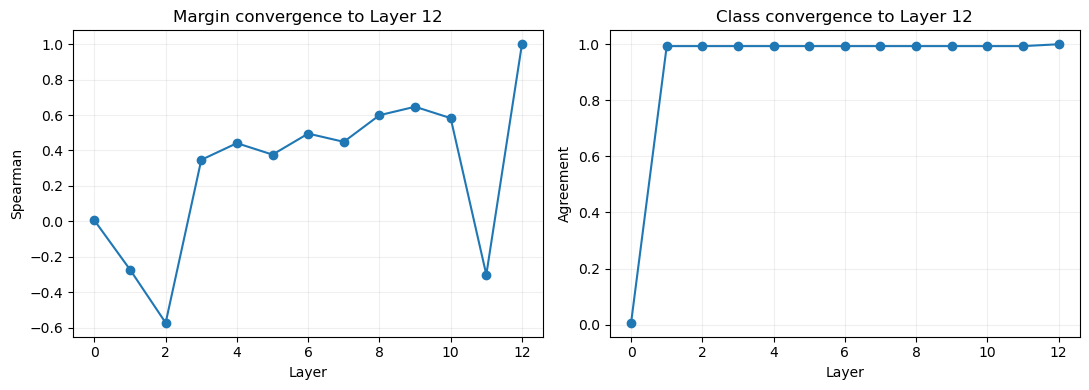

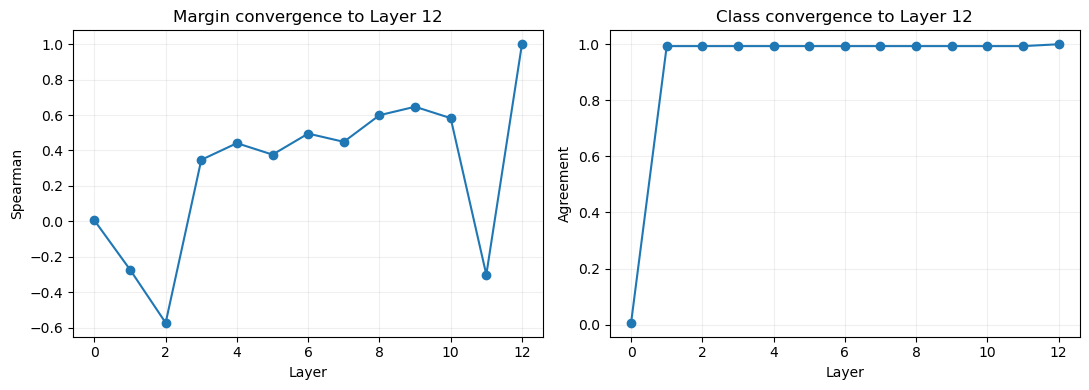

In [6]:
if RUN_STAGE_2A_FIXED_HEAD:
    fixed_head_dir = run_fixed_head_analysis_stage(config)
else:
    fixed_head_dir = RUN_DIR / 'fixed_head_analysis'
display(pd.Series(validate_fixed_head_analysis_outputs(fixed_head_dir)))
display(plot_fixed_head_convergence(fixed_head_dir))

## 4. Outcome-blind 对齐与年度 fold 审计

Validation 对齐最多读取到 2022-12-31 的 feature，绝不加载 2023 final-test feature。每个年度分别记录训练行数、评价行数和训练 Label cutoff。

In [7]:
aligned_dir = align_walk_forward_targets(config)
display(pd.Series(validate_walk_forward_targets(aligned_dir)))
fold_counts = pd.read_csv(aligned_dir / 'walk_forward_fold_counts.csv')
display(fold_counts)
display(
    fold_counts.pivot_table(index='task_id', columns='fold', values=['training_rows', 'evaluation_rows'], aggfunc='first')
)

rows     6761412
tasks         21
folds          5
dtype: int64

,task_id,fold,training_rows,evaluation_rows,training_label_cutoff,selection_label_cutoff
0,delta_log_dispersion__1m__active__fh0,validation_2018,92400,29276,2017-12-31,2022-12-31
1,delta_log_dispersion__1m__active__fh0,validation_2019,121896,29229,2018-12-31,2022-12-31
2,delta_log_dispersion__1m__active__fh0,validation_2020,150954,33284,2019-12-31,2022-12-31
3,delta_log_dispersion__1m__active__fh0,validation_2021,184529,29092,2020-12-31,2022-12-31
4,delta_log_dispersion__1m__active__fh0,validation_2022,213554,37903,2021-12-31,2022-12-31
...,...,...,...,...,...,...
100,residual_signed_raw__fh2,validation_2018,21282,33854,2017-12-31,2022-12-31
101,residual_signed_raw__fh2,validation_2019,39374,35140,2018-12-31,2022-12-31
102,residual_signed_raw__fh2,validation_2020,68399,0,2019-12-31,2022-12-31
103,residual_signed_raw__fh2,validation_2021,105654,0,2020-12-31,2022-12-31


evaluation_rows                  \
fold                                  validation_2018 validation_2019   
task_id                                                                 
delta_log_dispersion__1m__active__fh0           29276           29229   
delta_log_dispersion__1m__active__fh1           27144           27179   
delta_log_dispersion__1m__active__fh2           11973           12653   
delta_log_dispersion__1m__fixed__fh0            38272           37730   
delta_log_dispersion__1m__fixed__fh1            35367           35310   
delta_log_dispersion__1m__fixed__fh2            18586           18835   
delta_log_dispersion__1m__market__fh0           37986           37546   
delta_log_dispersion__1m__market__fh1           35145           35131   
delta_log_dispersion__1m__market__fh2           18532           18772   
delta_log_dispersion__3m__active__fh0           37405           37103   
delta_log_dispersion__3m__active__fh1           36631           36401   
delta_log_dispersion__3m__active__fh2           19531           19738   
delta_log_dispersion__3m__fixed__fh0            41319           40661   
delta_log_dispersion__3m__fixed__fh1            39024           38978   
delta_log_dispersion__3m__fixed__fh2            21732           22126   
delta_log_dispersion__3m__market__fh0           40395           40008   
delta_log_dispersion__3m__market__fh1           38283           38407   
delta_log_dispersion__3m__market__fh2           21409           21781   
residual_signed_raw__fh0                        68979           66919   
residual_signed_raw__fh1                        63002           62187   
residual_signed_raw__fh2                        33854           35140   

                                                                       \
fold                                  validation_2020 validation_2021   
task_id                                                                 
delta_log_dispersion__1m__active__fh0           33284           29092   
delta_log_dispersion__1m__active__fh1           30816           27976   
delta_log_dispersion__1m__active__fh2           14562           15096   
delta_log_dispersion__1m__fixed__fh0            42129           38621   
delta_log_dispersion__1m__fixed__fh1            39241           37212   
delta_log_dispersion__1m__fixed__fh2            21277           22053   
delta_log_dispersion__1m__market__fh0           41947           38450   
delta_log_dispersion__1m__market__fh1           39086           37020   
delta_log_dispersion__1m__market__fh2           21242           21993   
delta_log_dispersion__3m__active__fh0           41557           38255   
delta_log_dispersion__3m__active__fh1           40201           38356   
delta_log_dispersion__3m__active__fh2           22416           23015   
delta_log_dispersion__3m__fixed__fh0            45365           42193   
delta_log_dispersion__3m__fixed__fh1            43202           41592   
delta_log_dispersion__3m__fixed__fh2            24636           25960   
delta_log_dispersion__3m__market__fh0           44729           41563   
delta_log_dispersion__3m__market__fh1           42649           40982   
delta_log_dispersion__3m__market__fh2           24371           25641   
residual_signed_raw__fh0                        73011           67294   
residual_signed_raw__fh1                        67763               0   
residual_signed_raw__fh2                            0               0   

                                                        training_rows  \
fold                                  validation_2022 validation_2018   
task_id                                                                 
delta_log_dispersion__1m__active__fh0           37903           92400   
delta_log_dispersion__1m__active__fh1           35995           79585   
delta_log_dispersion__1m__active__fh2           20965           28844   
delta_log_dispersion__1m__fixed__fh0            48500          138140   
delta_log_dispersion_

## 5. Scheme A+：固定头与连续 Label 的 walk-forward 关联

仍不训练模型。只使用在 2022-12-31 前已经可知的 validation outcomes，并分别报告每年和合并后的 Spearman/Pearson。

metric_rows    1560
tasks            21
dtype: int64

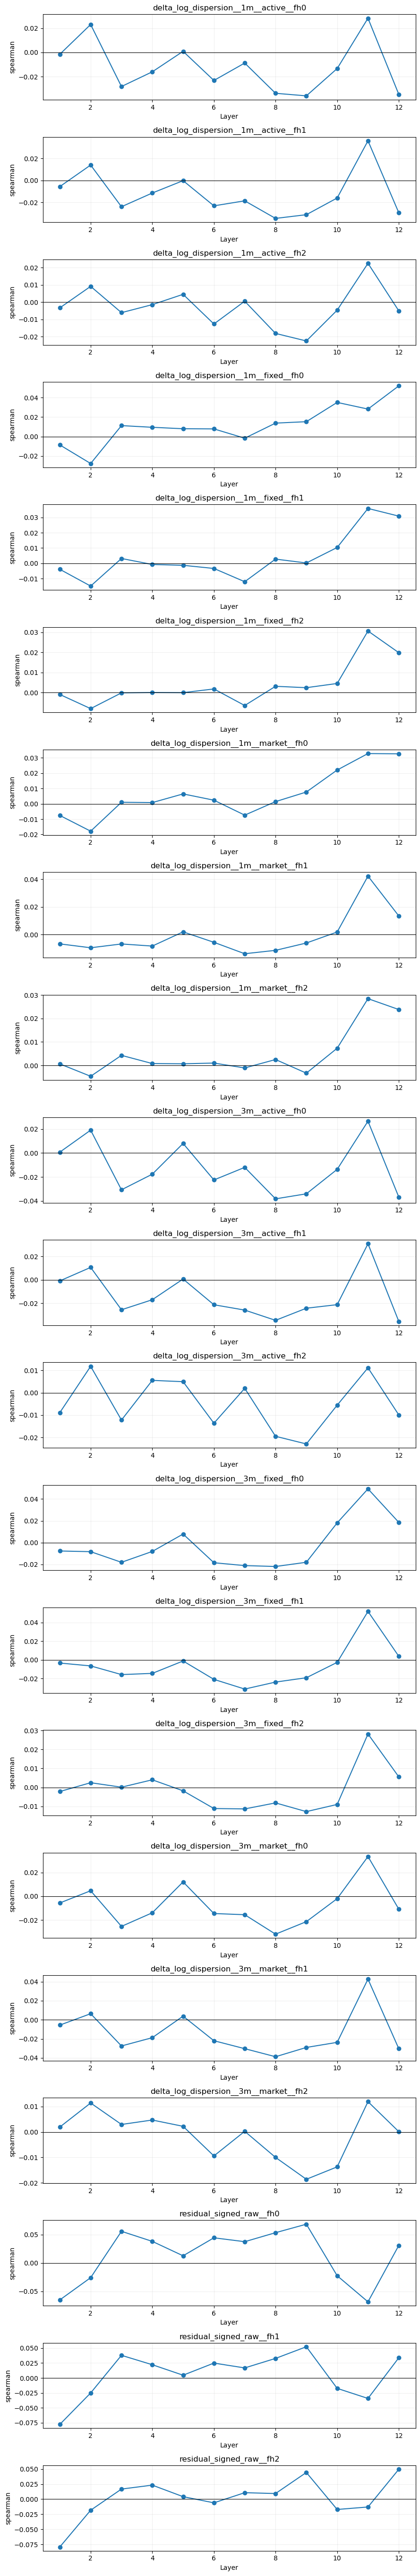

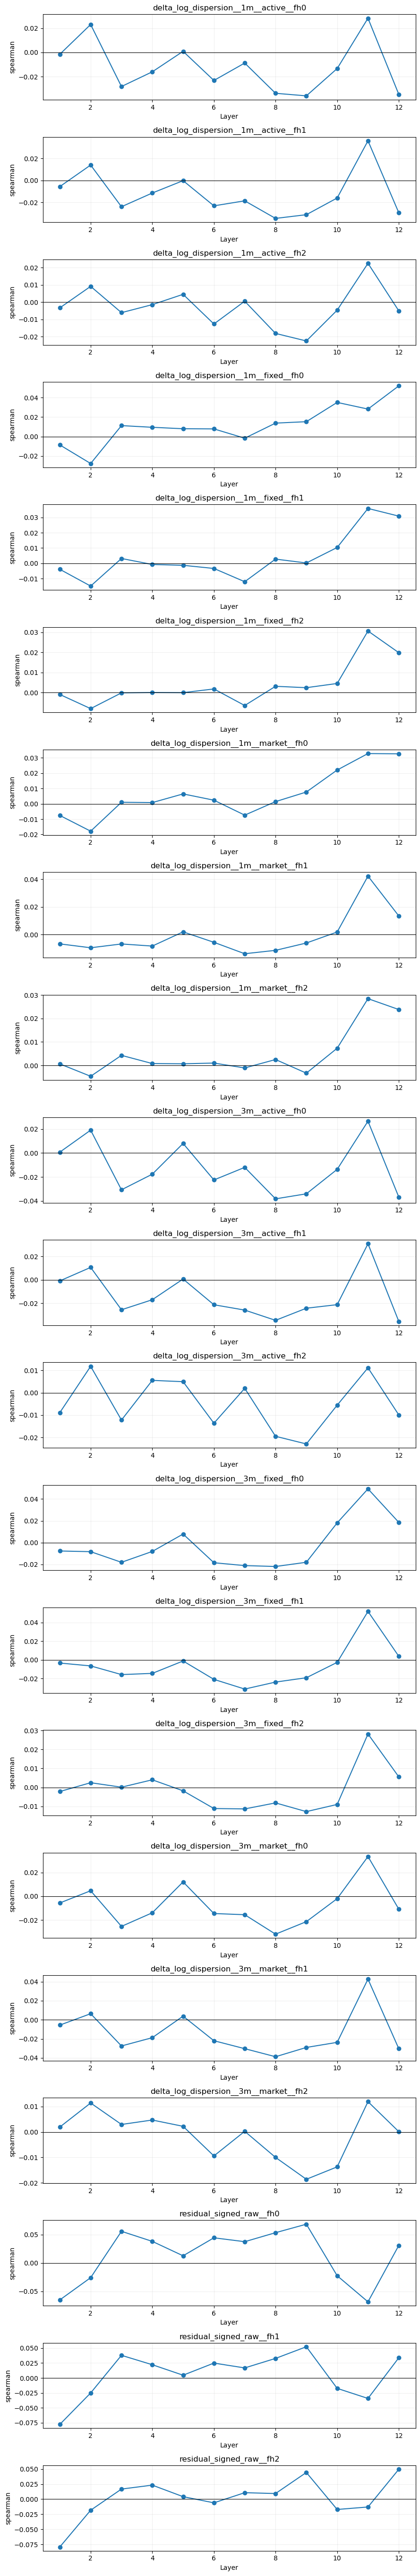

In [8]:
if RUN_STAGE_2A_PLUS_ASSOCIATION:
    association_dir = run_walk_forward_fixed_head_stage(config)
else:
    association_dir = RUN_DIR / 'walk_forward_fixed_head_label' / 'validation'
display(pd.Series(validate_walk_forward_fixed_head_outputs(association_dir)))
display(plot_walk_forward_fixed_head_curves(association_dir))

## 6. Scheme B：年度扩展 StandardScaler + Ridge

对每个 task、layer、年度 fold 独立拟合。训练资格同时要求 `feature < fold_start` 和 `label_available < fold_start`。alpha 按各有效年度等权平均 Spearman 选择；并列时取更强正则。

In [ ]:
if RUN_STAGE_2B_WALK_FORWARD_PROBE:
    walk_forward_probe_dir = run_walk_forward_probe_stage(config)
else:
    walk_forward_probe_dir = RUN_DIR / 'walk_forward_probe' / 'validation'
display(pd.Series(validate_walk_forward_probe_outputs(walk_forward_probe_dir)))
selected_alphas = pd.read_csv(walk_forward_probe_dir / 'walk_forward_selected_alphas.csv')
display(selected_alphas)
display(plot_walk_forward_probe_curves(walk_forward_probe_dir))

ValueError: walk-forward probe未覆盖全部任务或13层: missing_tasks=[]

: 

## 7. 股票日 representation 与未来收益

将同一股票同一交易日的文本 representation 逐层取均值，连接未来 1/5/20 日行业调整收益。最长20日窗口跨越下一 split 的样本会被 purge。

In [ ]:
if RUN_STAGE_3_STOCK_DAY:
    run_stock_day_panel_stage(config, 'validation')
stock_day_root = RUN_DIR / 'stock_day_panel'
display(pd.Series(validate_stock_day_artifacts(stock_day_root, evaluation_split='validation')))
display(plot_stock_day_summary(stock_day_root, evaluation_split='validation'))

## 8. 直接收益 Layer Probe

这一部分直接用各层股票日 representation 预测未来5日收益排名，与连续 Label probe 是独立问题。

In [ ]:
if RUN_STAGE_4_DIRECT_RETURN_PROBE:
    return_probe_dir = run_return_probe_stage(config, 'validation')
else:
    return_probe_dir = RUN_DIR / 'return_probe' / 'validation'
display(pd.Series(validate_return_probe_outputs(return_probe_dir)))
display(plot_return_curve(return_probe_dir, split='validation'))

## 9. 两类连续 Label 的 OOS 因子收益

把 Scheme B 的严格 OOS 预测按 `task × layer × stock × trading_date` 做无权均值，再计算未来1/5/20日 Rank IC、ICIR、分组收益和顶底收益差。`target_weight` 可能含未来信息，因此不会参与因子聚合。真实 Label 与收益的关系单独标记为不可交易的事后诊断。

In [ ]:
if RUN_STAGE_4B_LABEL_FACTOR_RETURNS:
    label_factor_dir = run_label_factor_return_stage(config)
else:
    label_factor_dir = RUN_DIR / 'label_factor_returns' / 'validation'
display(pd.Series(validate_label_factor_return_outputs(label_factor_dir)))
label_factor_summary = pd.read_csv(label_factor_dir / 'label_factor_summary.csv')
display(label_factor_summary)
display(plot_label_factor_ic_curves(label_factor_dir, horizon=5))
display(pd.read_csv(label_factor_dir / 'realized_label_return_diagnostic.csv'))

## 10. 各层因子的相关性

分别对连续 Label OOS 因子和直接收益因子，逐日计算股票横截面上的 Layer 0～12 Spearman 相关矩阵，再对日期汇总。

In [ ]:
if RUN_STAGE_4C_LAYER_CORRELATIONS:
    correlation_dir = run_layer_factor_correlation_stage(config)
else:
    correlation_dir = RUN_DIR / 'layer_factor_correlations' / 'validation'
display(pd.Series(validate_layer_factor_correlation_outputs(correlation_dir)))
correlation_summary = pd.read_csv(correlation_dir / 'layer_correlation_summary.csv')
display(correlation_summary)
display(plot_layer_correlation_heatmap(correlation_dir, factor_source='direct_return_probe', task_id='direct_return_target'))
display(plot_layer_correlation_heatmap(correlation_dir, factor_source='continuous_label_probe', task_id='residual_signed_raw__fh0'))
display(plot_layer_correlation_heatmap(correlation_dir, factor_source='continuous_label_probe', task_id='delta_log_dispersion__3m__fixed__fh0'))

## 11. 跨层收益因子（阶段5～6）

在直接收益 OOS 预测上比较 single layer、consensus、disagreement、deep-minus-middle、deep residual 和 PCA 因子。只查看 validation；候选选择和预注册完成前不打开 test。

In [ ]:
if RUN_STAGE_5_6_FACTOR_VALIDATION:
    factor_dir = run_factor_validation_stage(config, 'validation')
else:
    factor_dir = RUN_DIR / 'factor_validation' / 'validation'
display(pd.Series(validate_factor_outputs(factor_dir)))
display(pd.read_csv(factor_dir / 'factor_summary.csv'))
display(plot_factor_summary(factor_dir))

## 12. Validation 产物总览与 final-test 闸门

Run All 到这里即完成全历史 validation 主线。2023 test 只有在候选因子、alpha 规则和预期方向预注册后才能另行开启；本 Notebook 当前不会读取或评价 test Label。

In [ ]:
validation_outputs = {
    'representation': REPRESENTATION_DIR / 'representation_manifest.json',
    'fixed_head': fixed_head_dir / 'manifest.json',
    'walk_forward_targets': aligned_dir / 'manifest.json',
    'walk_forward_fixed_head_label': association_dir / 'manifest.json',
    'walk_forward_probe': walk_forward_probe_dir / 'manifest.json',
    'stock_day': stock_day_root / 'validation' / 'stock_day_manifest.json',
    'return_probe': return_probe_dir / 'manifest.json',
    'label_factor_returns': label_factor_dir / 'manifest.json',
    'layer_correlations': correlation_dir / 'manifest.json',
    'factor_validation': factor_dir / 'manifest.json',
}
summary = []
for stage, path in validation_outputs.items():
    summary.append({'stage': stage, 'path': str(path), 'exists': path.is_file()})
summary = pd.DataFrame(summary)
display(summary)
assert summary['exists'].all(), '部分validation阶段缺少manifest'

if RUN_FINAL_TEST:
    raise RuntimeError('2023 final test仍封闭：先冻结validation候选、alpha、方向与判定规则，再使用一次性test入口')